In [ ]:
import os
import pathlib
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np

In [3]:

CICAPT_FLOWS_PATH = pathlib.Path('../datasets/cherry-picked/cicapt/phase2_NetworkData.csv')

In [4]:
cicapt_flows = pd.read_csv(CICAPT_FLOWS_PATH)

/tmp/ipykernel_2762159/706178152.py:1: DtypeWarning: Columns (0: subLabel, 1: subLabelCat) have mixed types. Specify dtype option on import or set low_memory=False.
  cicapt_flows = pd.read_csv(CICAPT_FLOWS_PATH)


In [5]:
cicapt_flows.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
ts,9536823.0,1.701600e+09,7.498601e+04,1.701469e+09,1.701537e+09,1.701599e+09,1.701665e+09,1.701728e+09
flow_duration,9536823.0,5.154993e+02,8.292789e+02,0.000000e+00,1.686811e-02,1.186471e-01,8.941177e+02,2.985000e+03
Header_Length,9536823.0,5.672949e+05,1.128682e+06,0.000000e+00,1.234000e+03,2.462000e+03,8.321895e+05,9.778788e+06
Source Port,9536823.0,2.587172e+04,2.386792e+04,0.000000e+00,1.883000e+03,3.435400e+04,5.168200e+04,6.551500e+04
Destination Port,9536823.0,2.336748e+04,2.448048e+04,0.000000e+00,5.020000e+02,1.900000e+03,5.205300e+04,6.186700e+04
...,...,...,...,...,...,...,...,...
Sequence number,9536823.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
Protocol Version,9536823.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
flow_idle_time,9536823.0,2.676058e+07,2.117065e+08,0.000000e+00,3.678799e-04,2.001047e-03,2.127886e-03,1.701728e+09
flow_active_time,9536823.0,5.154993e+02,8.292789e+02,0.000000e+00,1.686811e-02,1.186471e-01,8.941177e+02,2.985000e+03


In [6]:
cicapt_flows.columns

Index(['ts', 'flow_duration', 'Header_Length', 'Source IP', 'Destination IP',
       'Source Port', 'Destination Port', 'Protocol Type', 'Protocol_name',
       'Duration', 'Rate', 'Srate', 'Drate', 'fin_flag_number',
       'syn_flag_number', 'rst_flag_number', 'psh_flag_number',
       'ack_flag_number', 'urg_flag_number', 'ece_flag_number',
       'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'urg_count',
       'rst_count', 'max_duration', 'min_duration', 'sum_duration',
       'average_duration', 'std_duration', 'CoAP', 'HTTP', 'HTTPS', 'DNS',
       'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP',
       'IGMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size',
       'IAT', 'Number', 'MAC', 'Magnitue', 'Radius', 'Covariance', 'Variance',
       'Weight', 'DS status', 'Fragments', 'Sequence number',
       'Protocol Version', 'flow_idle_time', 'flow_active_time', 'label',
       'subLabel', 'subLabelCat'],
      dtype='str')

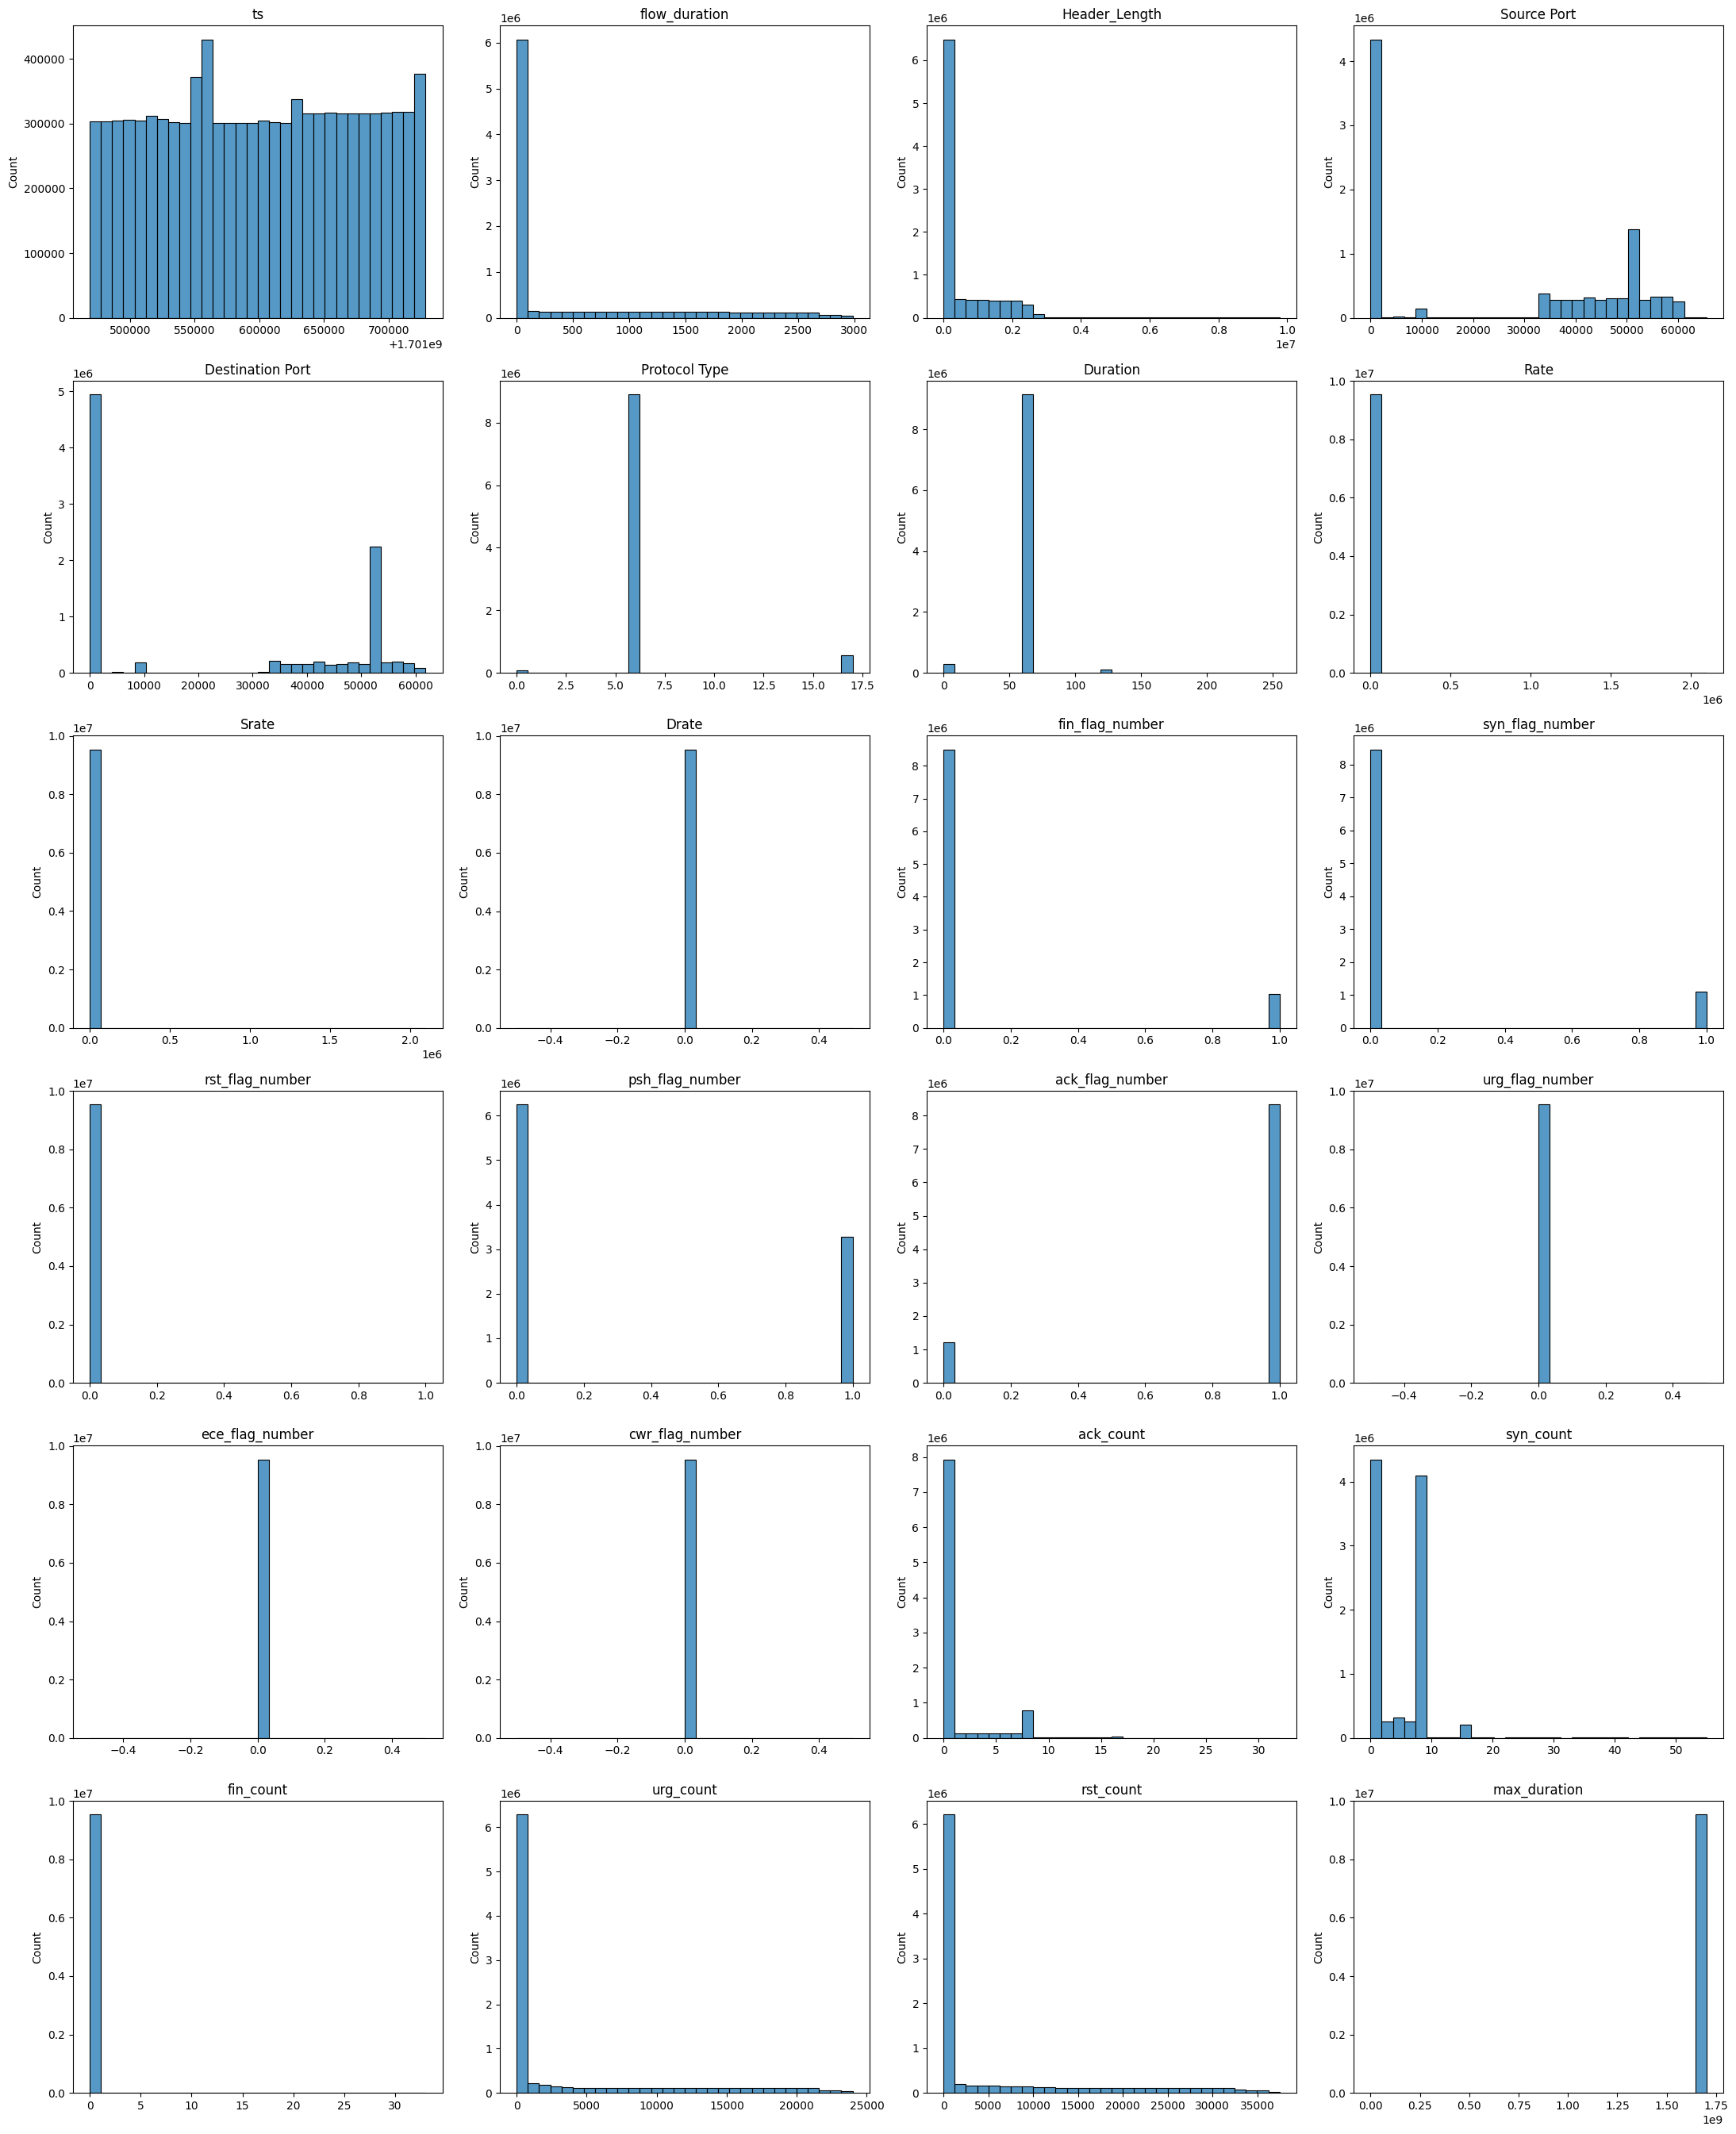

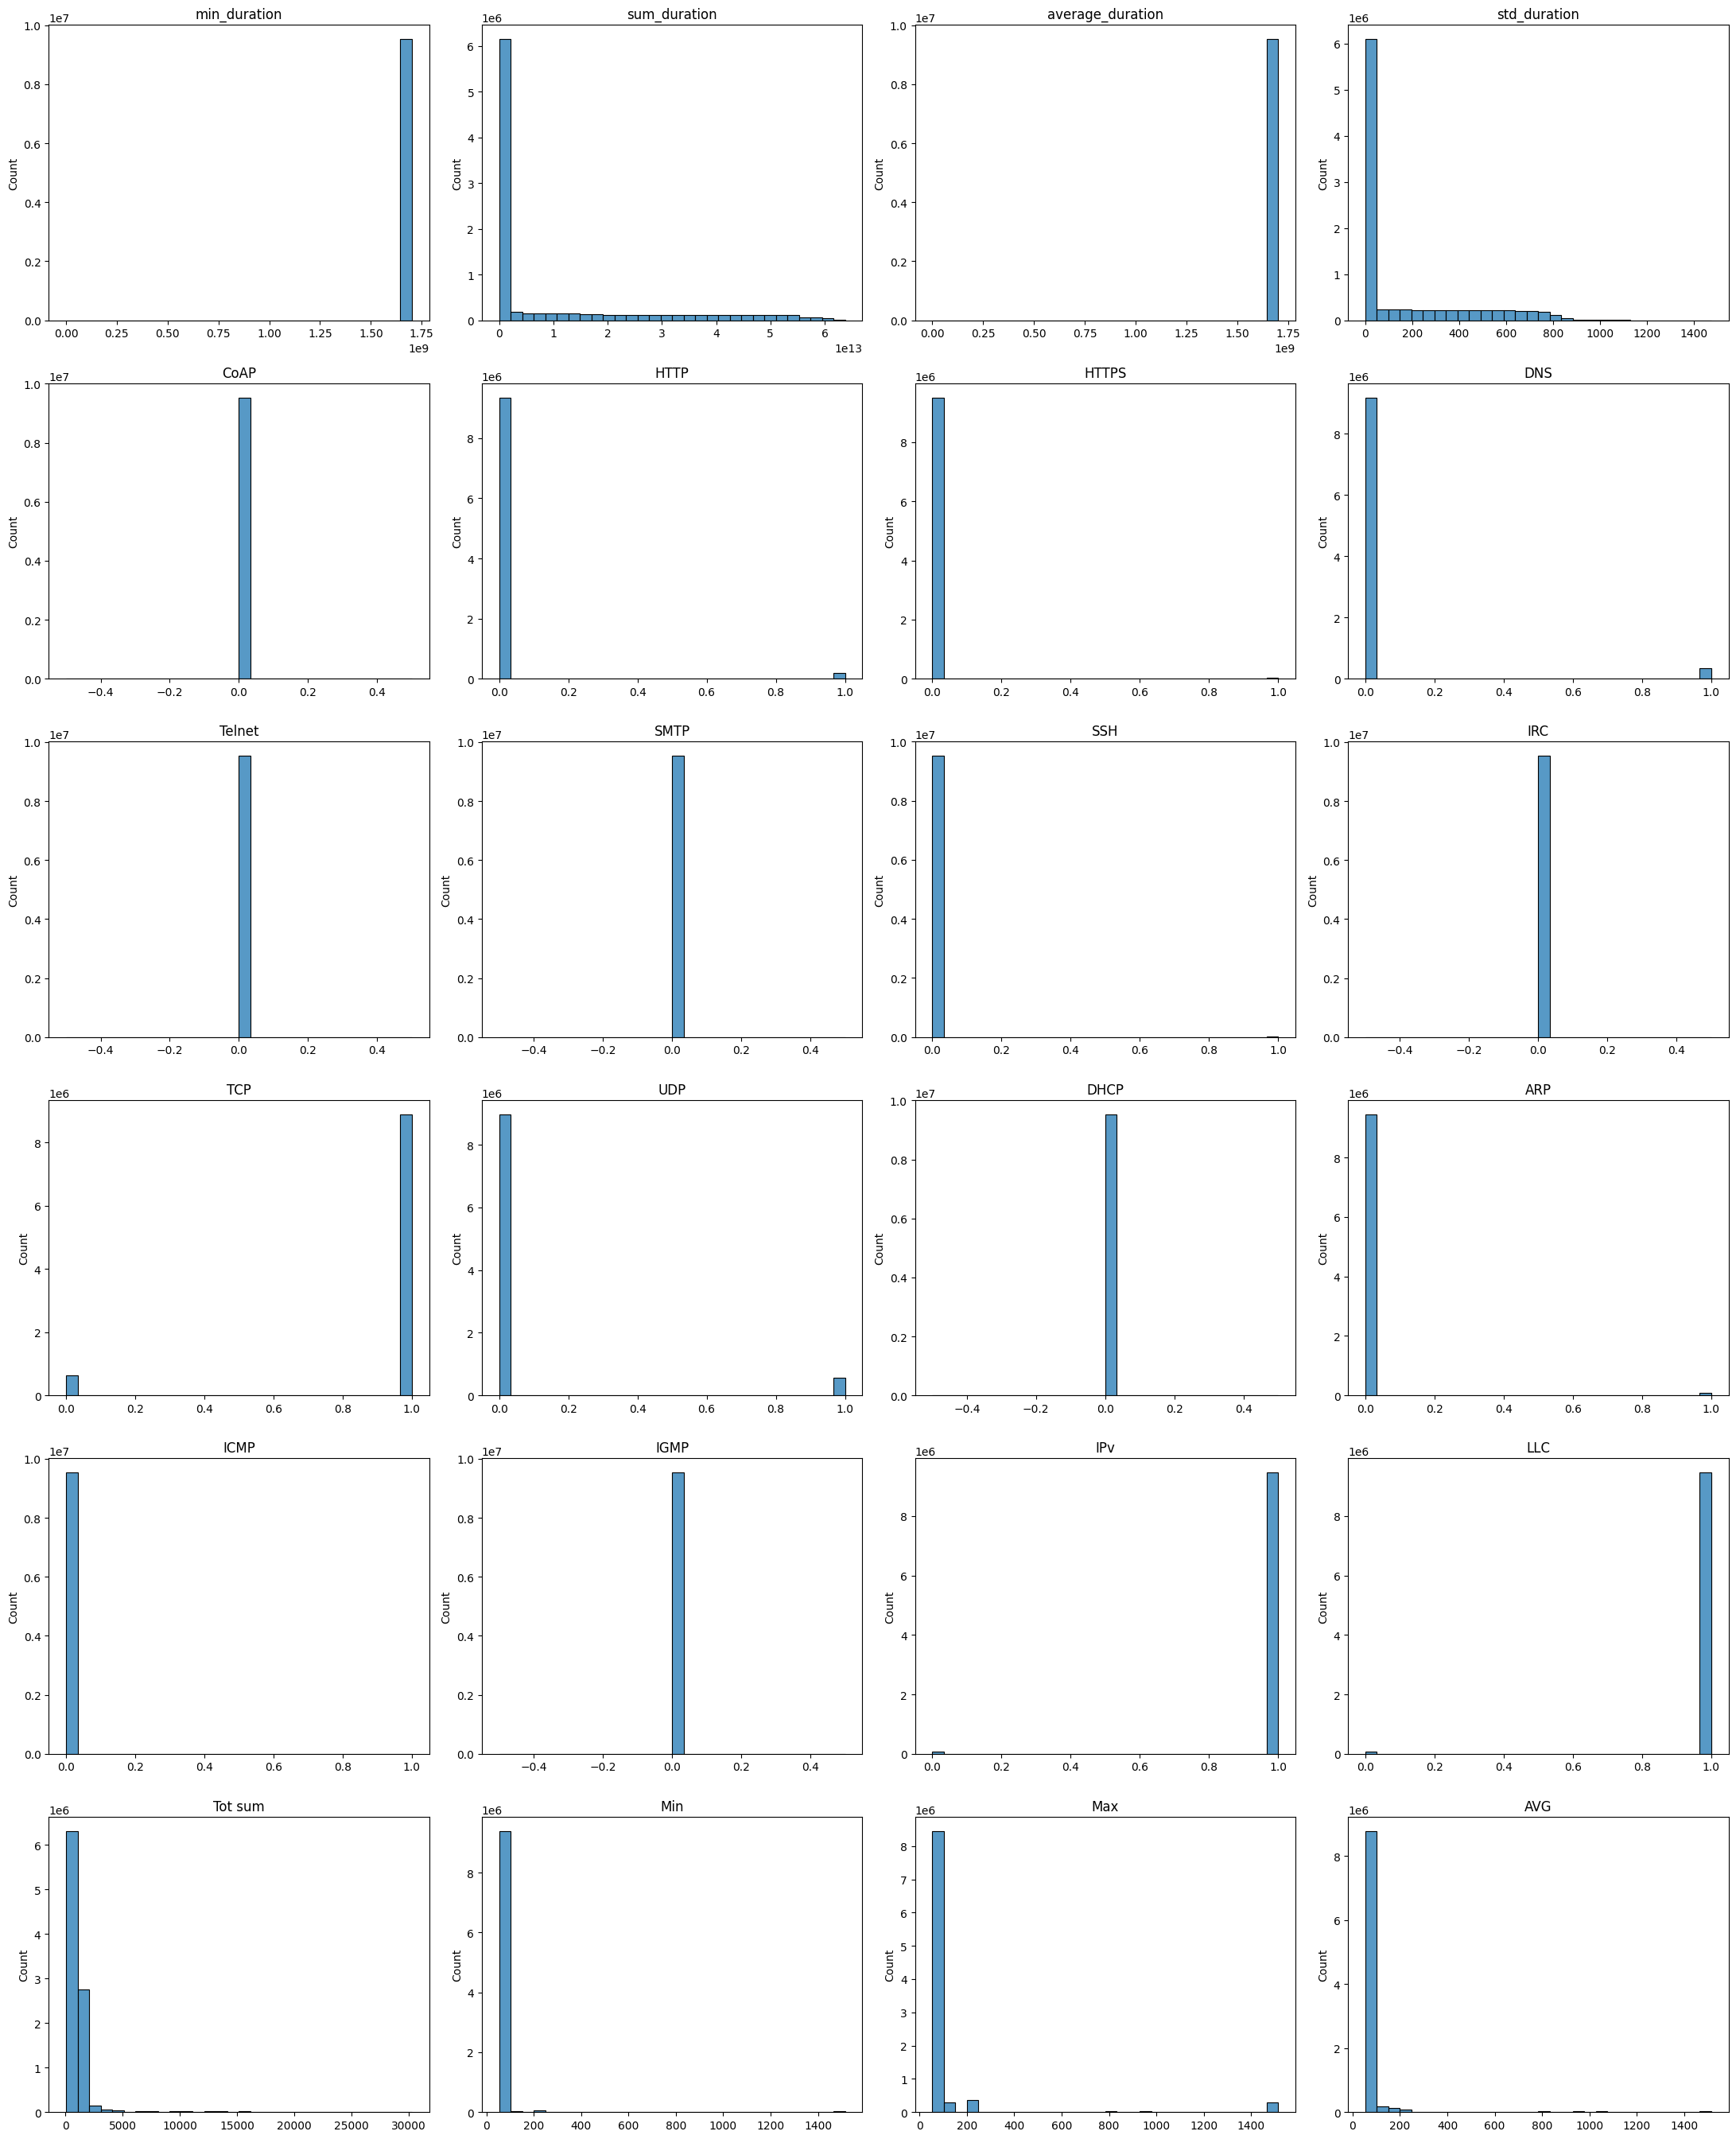

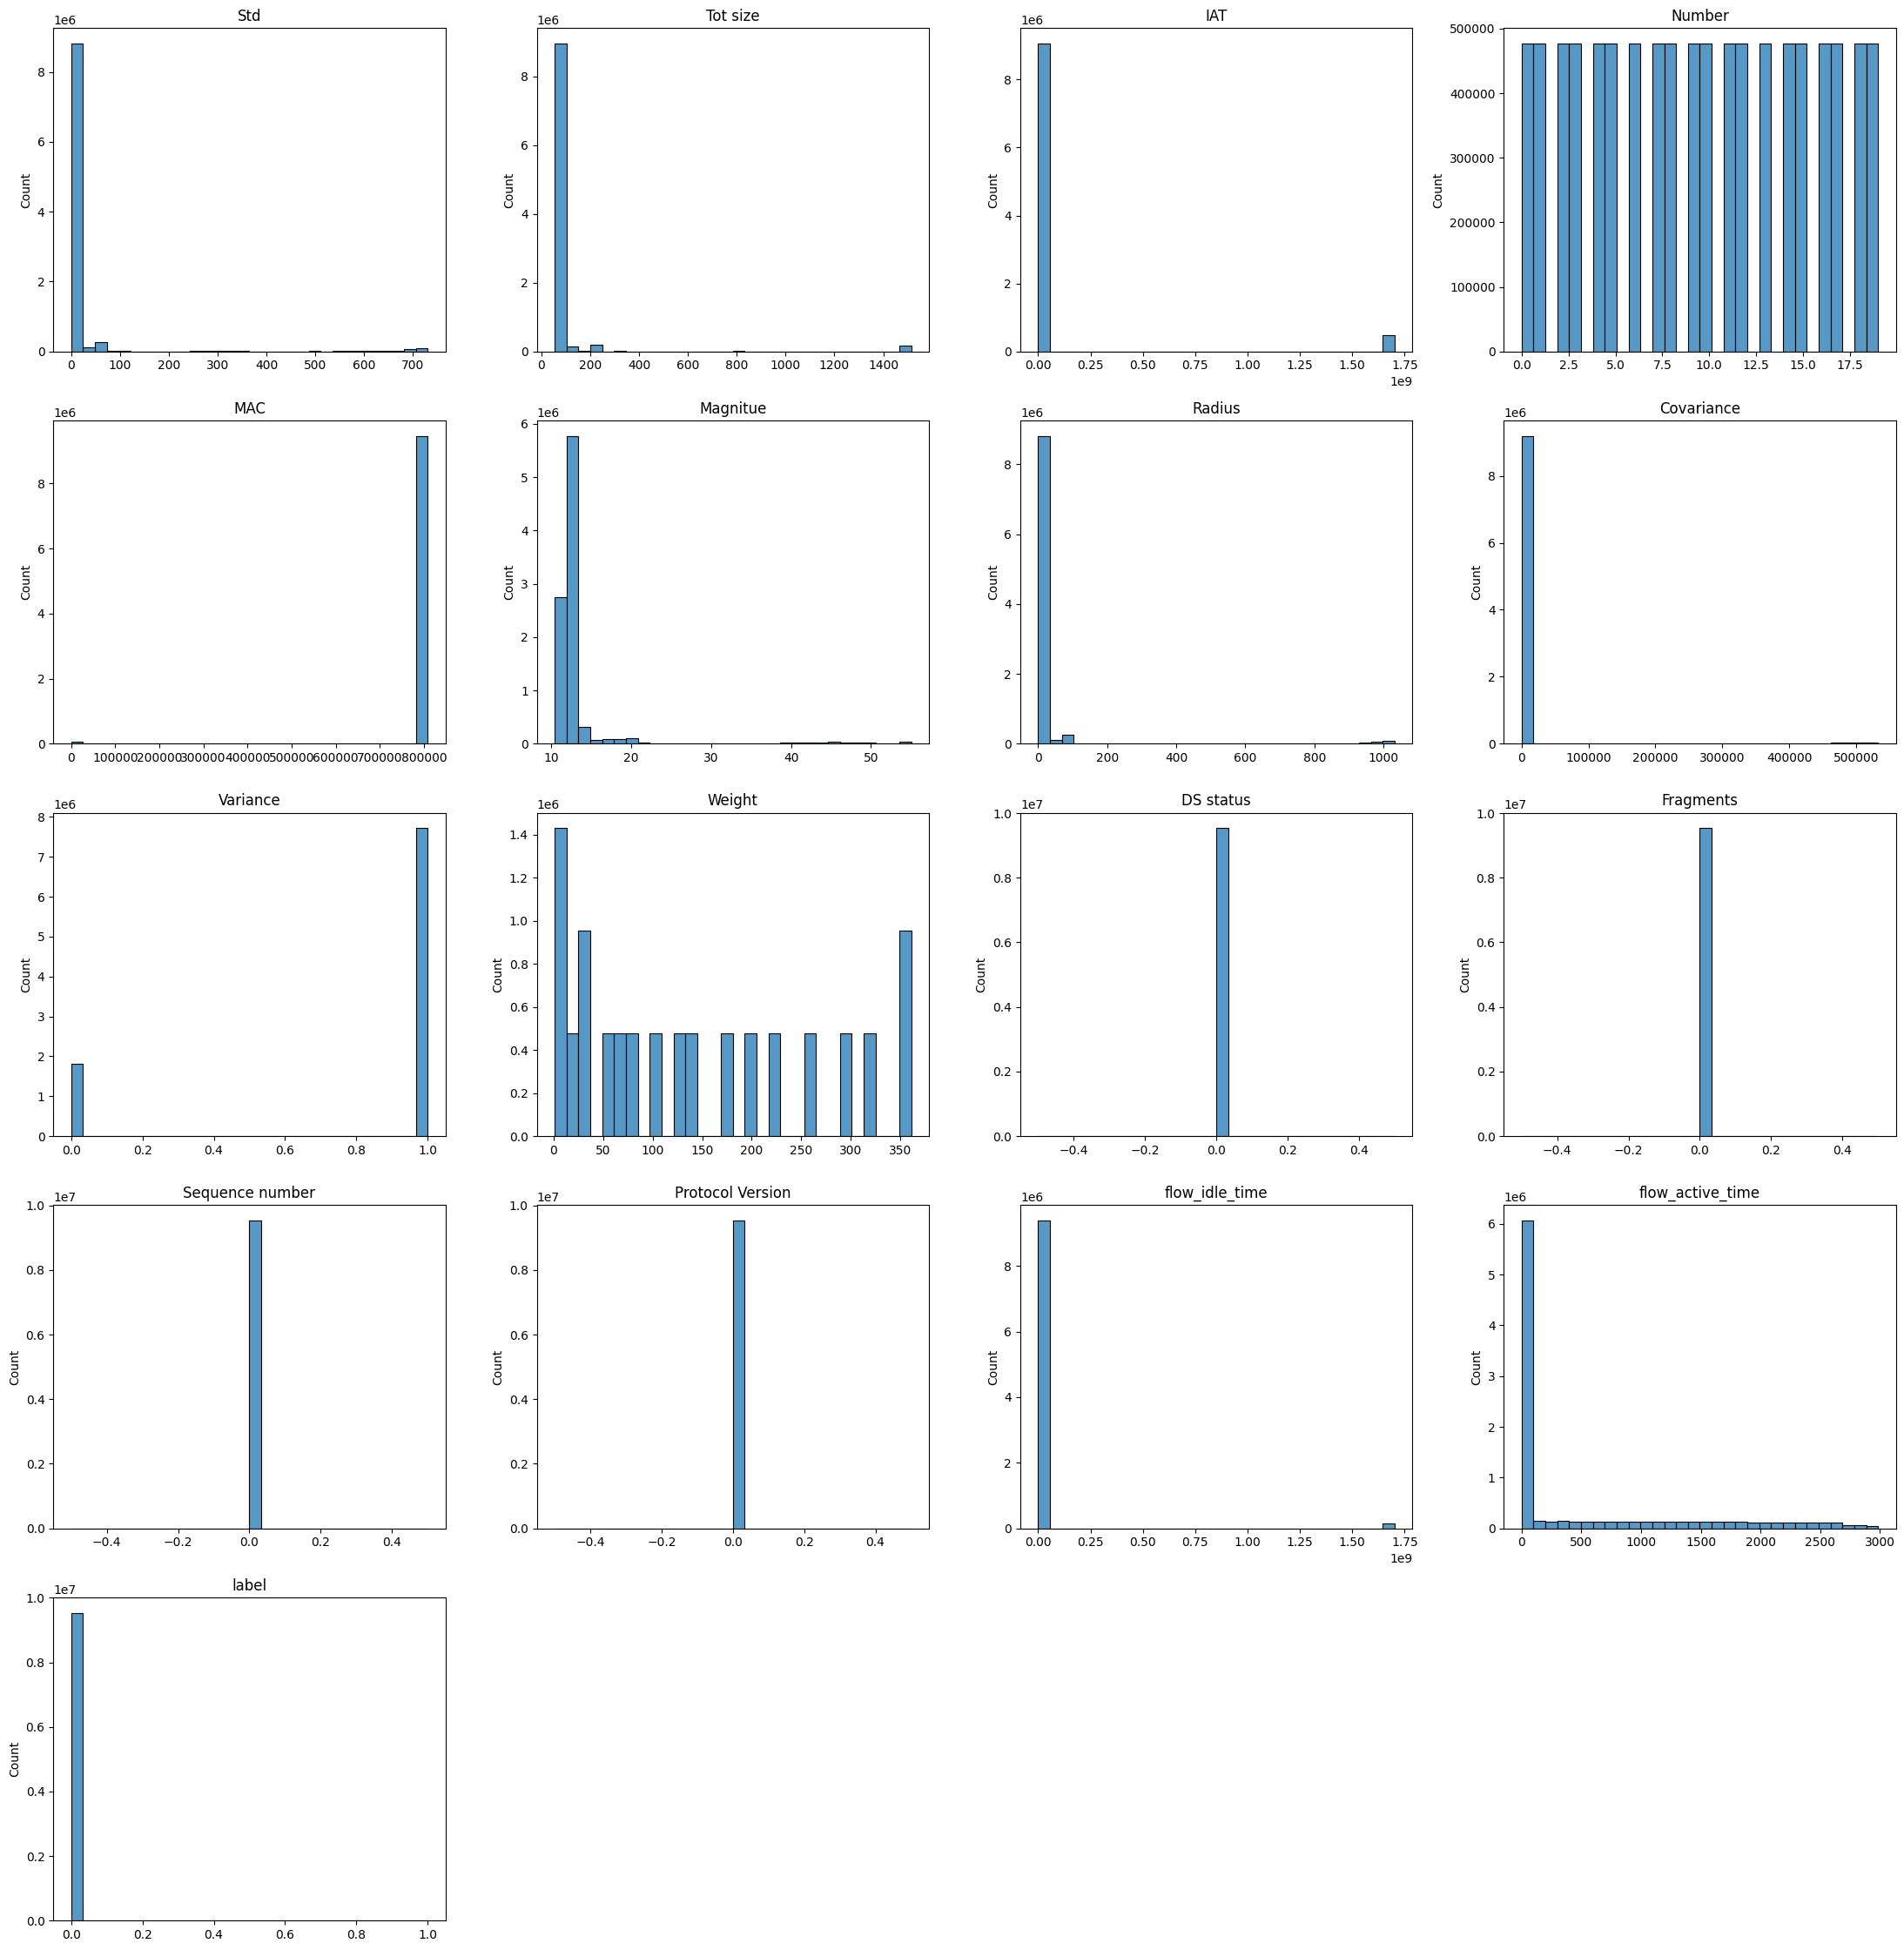

In [7]:
data = cicapt_flows if 'unraveled_flows' in globals() and not cicapt_flows.empty else cicapt_flows

num_cols = data.select_dtypes(include=np.number).columns.tolist()
n_per_fig = 24
n_cols = 4

for start in range(0, len(num_cols), n_per_fig):
    cols_chunk = num_cols[start:start + n_per_fig]
    n_rows = int(np.ceil(len(cols_chunk) / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, 4.5 * n_rows))
    axes = np.array(axes).reshape(-1)
    
    for ax, col in zip(axes, cols_chunk):
        sns.histplot(data[col].dropna(), bins=30, kde=False, ax=ax)
        ax.set_title(col)
        ax.set_xlabel("")
    
    for ax in axes[len(cols_chunk):]:
        ax.axis("off")
    
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_2762159/3811955745.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = data.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()


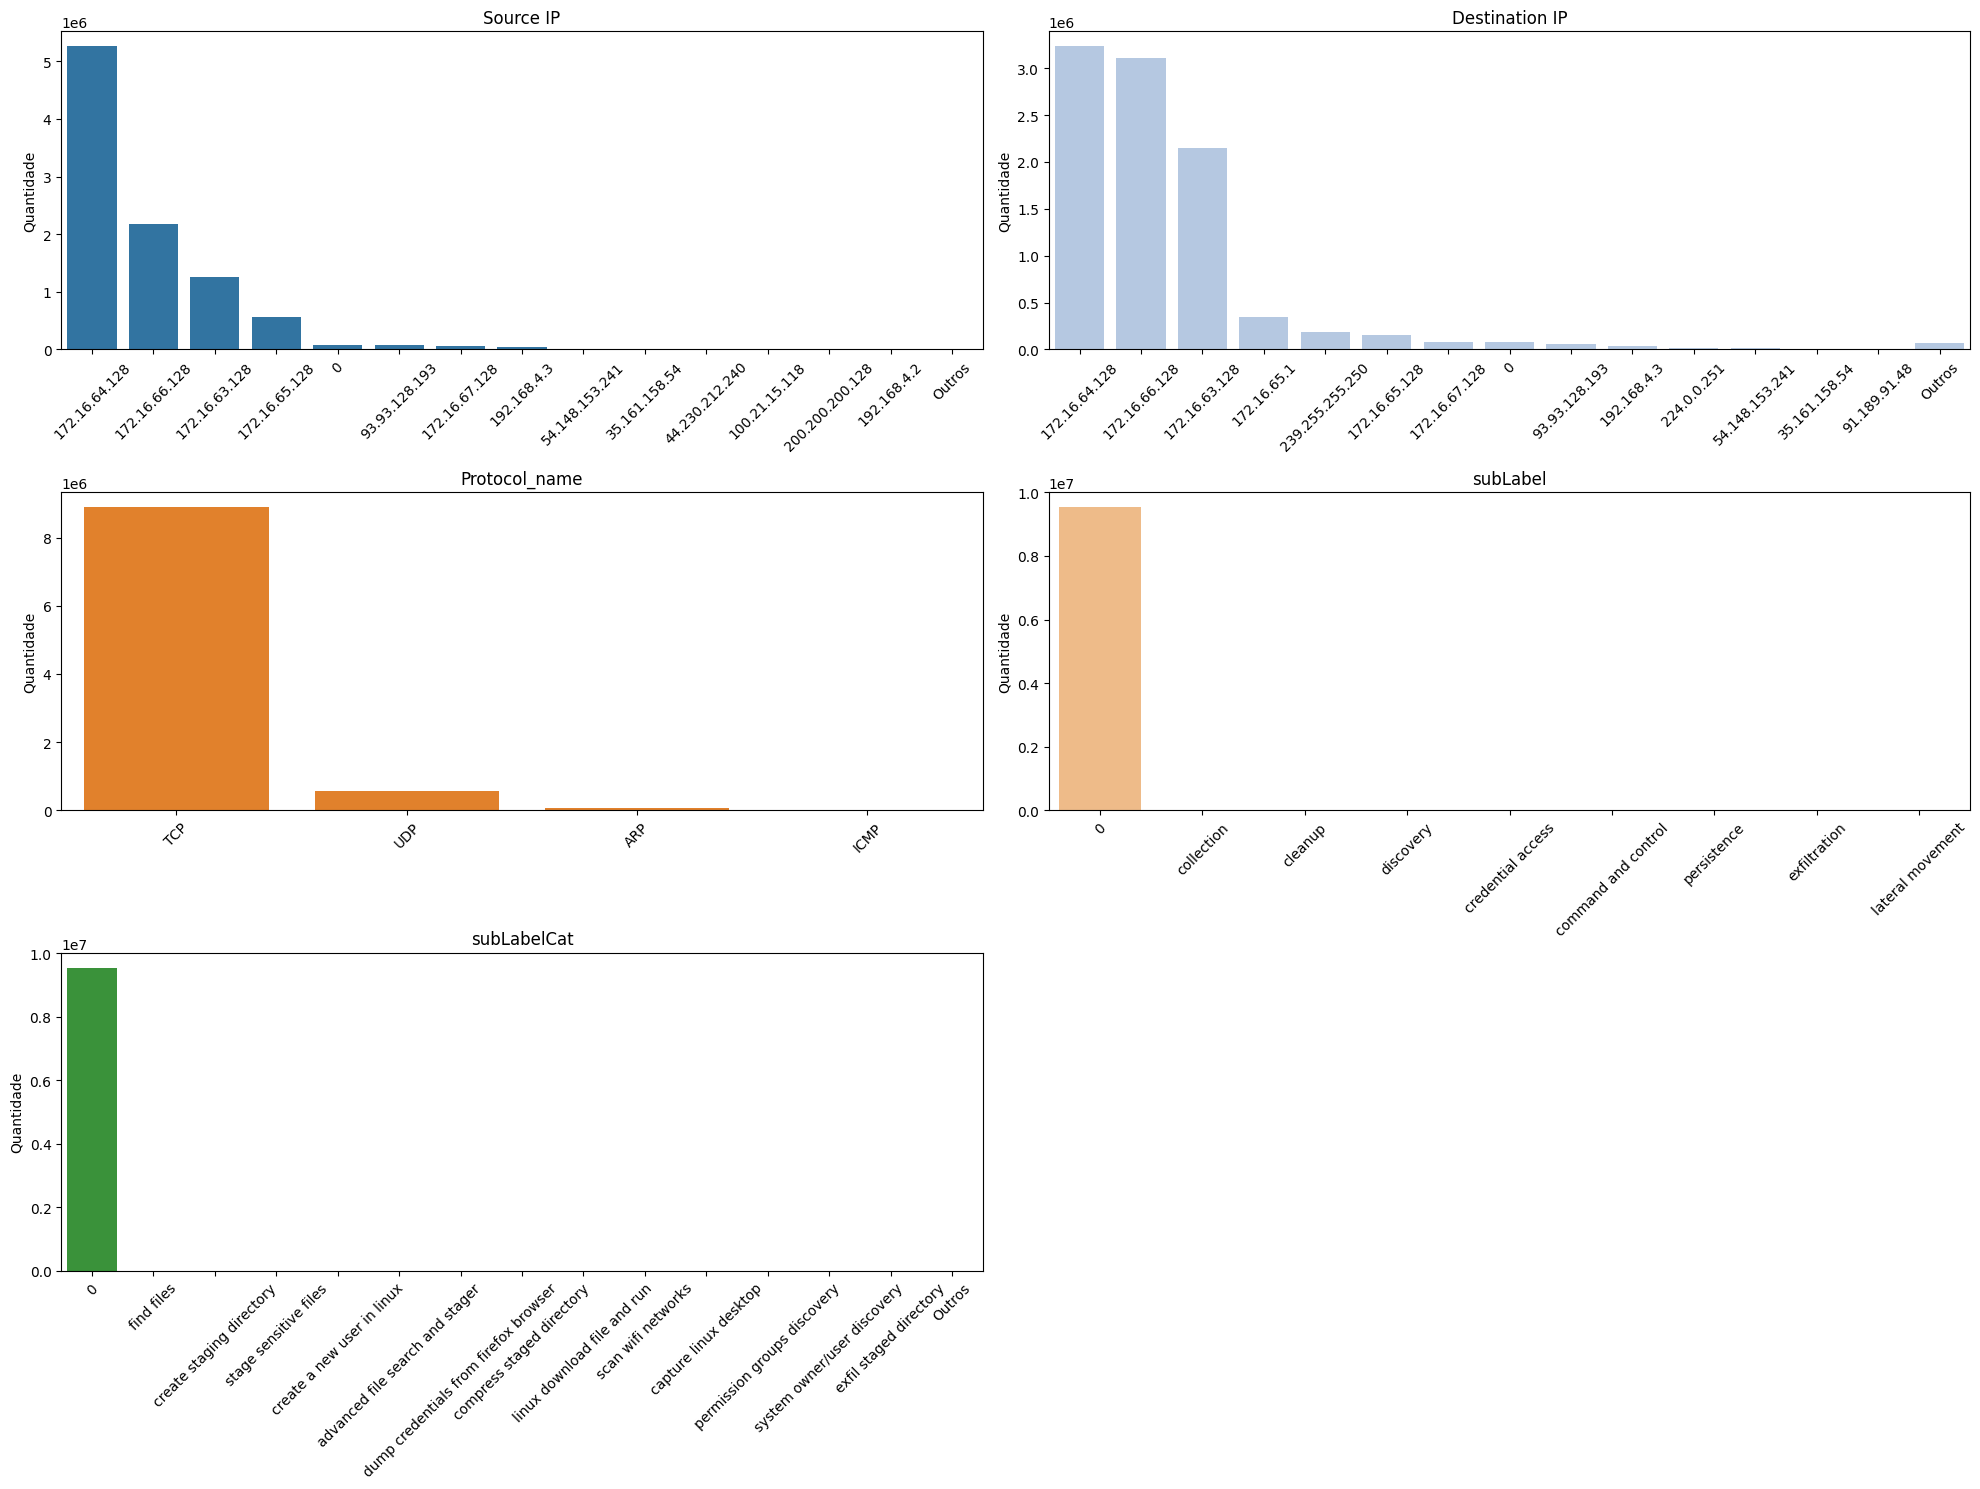

In [8]:

cat_cols = data.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
n_per_fig = 8
n_cols = 2
max_categories = 15
palette = plt.cm.tab20.colors

for start in range(0, len(cat_cols), n_per_fig):
    cols_chunk = cat_cols[start:start + n_per_fig]
    n_rows = int(np.ceil(len(cols_chunk) / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
    axes = np.array(axes).reshape(-1)
    
    for i, (ax, col) in enumerate(zip(axes, cols_chunk)):
        vc = data[col].fillna("NaN").astype(str).value_counts()
        if len(vc) > max_categories:
            vc = pd.concat([vc.head(max_categories - 1), pd.Series({"Outros": vc.iloc[max_categories - 1:].sum()})])
        
        color = palette[i % len(palette)]
        sns.barplot(x=vc.index, y=vc.values, ax=ax, color=color)
        ax.set_title(col)
        ax.set_xlabel("")
        ax.set_ylabel("Quantidade")
        ax.tick_params(axis='x', rotation=45)
    
    for ax in axes[len(cols_chunk):]:
        ax.axis("off")
    
    plt.tight_layout()
    plt.show()

In [12]:
print('Stage Distribution:')
for stage in cicapt_flows['label'].unique():
    print(f"  {stage}: {len(cicapt_flows[cicapt_flows['label'] == stage])}")
    
    for activity in cicapt_flows[cicapt_flows['label'] == stage]['subLabel'].unique():
        print(f"    {activity}: {len(cicapt_flows[(cicapt_flows['label'] == stage) & (cicapt_flows['subLabel'] == activity)])}")

Stage Distribution:
  0: 9535819
    0: 9110839
    0: 424980
  1: 1004
    discovery: 138
    collection: 460
    exfiltration: 42
    credential access: 58
    lateral movement: 14
    cleanup: 192
    persistence: 44
    command and control: 56
